In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
#load in data
published_data = pd.read_csv('Published Data/combined_COPUS_CI_data.csv')
measured_data = pd.read_csv('Measured Data/measured_data.csv')
data = pd.concat([published_data, measured_data], ignore_index=True)
labels = [ 'Lec', 'CG', 'CQ', 'WG', 'SQ']
WGs, CGs, CQs, SQs, Lecs, PQs = data['WG'].values, data['CG'].values, data['CQ'].values, data['SQ'].values, data['Lec'].values, data['PQ'].values
COPUS_data = data[labels].values
published_COPUS_data = published_data[labels].values
effect_sizes = data['Effect Size'].values
n_features = COPUS_data.shape[1]
post_stds = data['PostStd'].values
pre_stds = data['PreStd'].values
std_diffs = post_stds - pre_stds
premeans = data['PreMean'].values
postmeans = data['PostMean'].values
gains = postmeans - premeans

Ns = data['N'].values
Fields = data['Field'].values

## Covariance of Terms

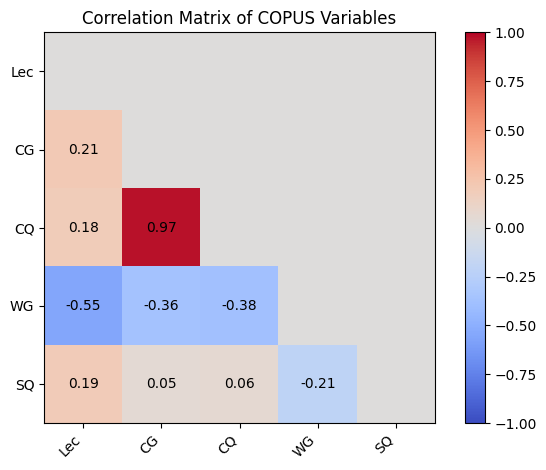

In [3]:
n_features = COPUS_data.shape[1]
corr = np.corrcoef(published_COPUS_data.T)


corr[corr == 1] = 0
#label each pixel with the numeric value
for i in range(n_features):
    for j in range(n_features):
        if j < i:
            plt.text(j, i, f'{corr[i, j]:.2f}', ha='center', va='center', color='black')
        else: corr[i,j] = 0
plt.imshow(corr, vmin = -1, vmax=1, cmap='coolwarm')
plt.colorbar()
plt.xticks(np.arange(n_features), labels, rotation=45, ha='right')
plt.yticks(np.arange(n_features), labels)
plt.title('Correlation Matrix of COPUS Variables')
plt.tight_layout()
plt.show()


## COPUS Codes vs. Summary Statistics

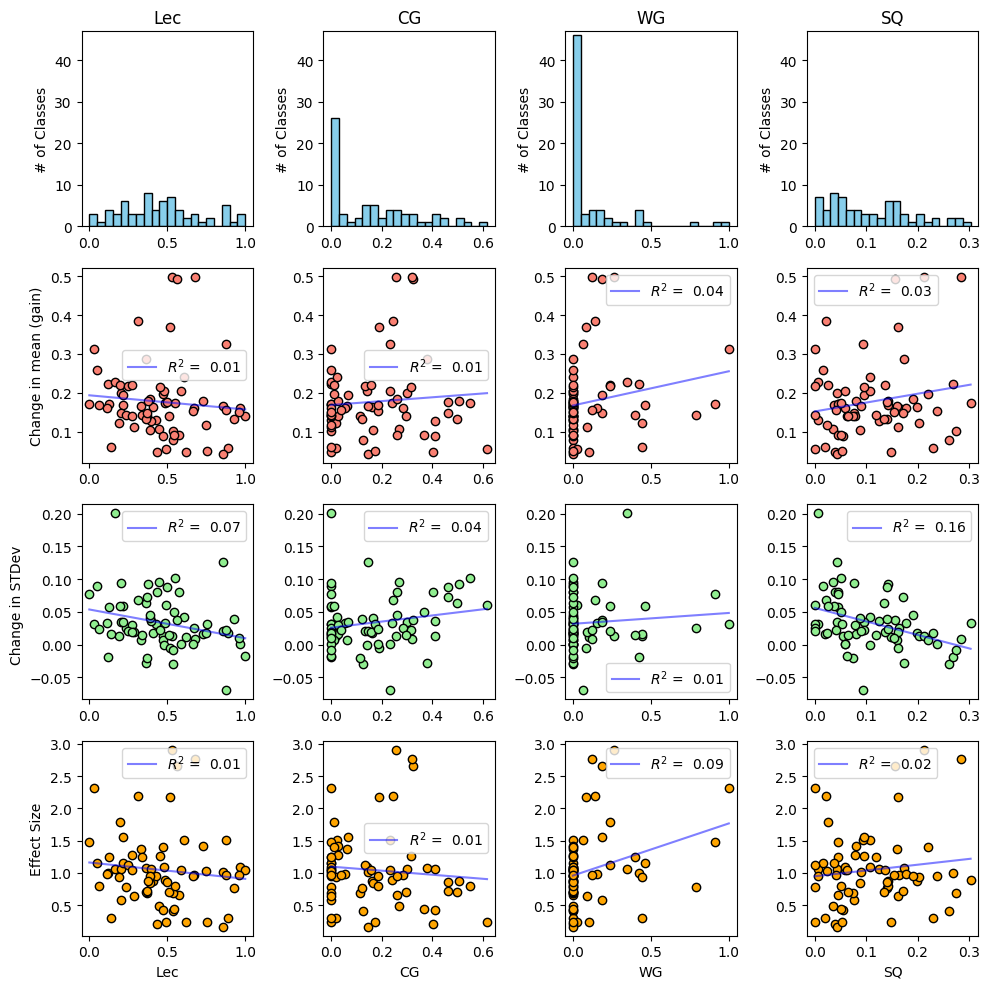

In [4]:
retained_labels = ['Lec', 'CG', 'WG', 'SQ']
n_features = len(retained_labels)
COPUS_data = data[retained_labels].values
fig, ax = plt.subplots(4, n_features, figsize=(10, 10))
for i in range(n_features):
    x0 = np.linspace(min(COPUS_data[:, i]), max(COPUS_data[:, i]), 100)

    ax[0, i].set_title(retained_labels[i])
    ax[0, i].hist(COPUS_data[:, i], bins=20, color='skyblue', edgecolor='black')
    ax[0, i].set_ylabel('# of Classes')
    ax[0,i].set_ylim(0, 47)
    
    ax[1, i].scatter(COPUS_data[:, i], gains, color='salmon', edgecolor='black')
    m, b = np.polyfit(COPUS_data[:, i], gains, 1)
    corr = np.corrcoef(COPUS_data[:, i], gains)[0, 1]**2
    ax[1, i].plot(x0, m*x0 + b, color='blue', label = f'$R^2$ =  {corr:.2f}', alpha = .5  )
    ax[1, i].legend()

    ax[2, i].scatter(COPUS_data[:, i], std_diffs, color='lightgreen', edgecolor='black')
    m, b = np.polyfit(COPUS_data[:, i], std_diffs, 1)
    corr = np.corrcoef(COPUS_data[:, i], std_diffs)[0, 1]**2
    ax[2, i].plot(x0, m*x0 + b, color='blue', label = f'$R^2$ =  {corr:.2f}', alpha = .5  )
    ax[2, i].legend()


    ax[3, i].scatter(COPUS_data[:, i], effect_sizes, color='orange', edgecolor='black')
    ax[3, i].set_xlabel(retained_labels[i])
    m, b = np.polyfit(COPUS_data[:, i], effect_sizes, 1)
    corr = np.corrcoef(COPUS_data[:, i], effect_sizes)[0, 1]**2
    ax[3, i].plot(x0, m*x0 + b, color='blue', label = f'$R^2$ =  {corr:.2f}', alpha = .5  )
    ax[3, i].legend()

ax[1, 0].set_ylabel('Change in mean (gain)')
ax[2, 0].set_ylabel('Change in STDev ')
ax[3, 0].set_ylabel('Effect Size')
#fig.suptitle('COPUS Variables vs. Outcomes')
fig.tight_layout()
plt.savefig('Figs/COPUS_dists.png', dpi=300)
plt.show()

## Effect Size vs. Gains

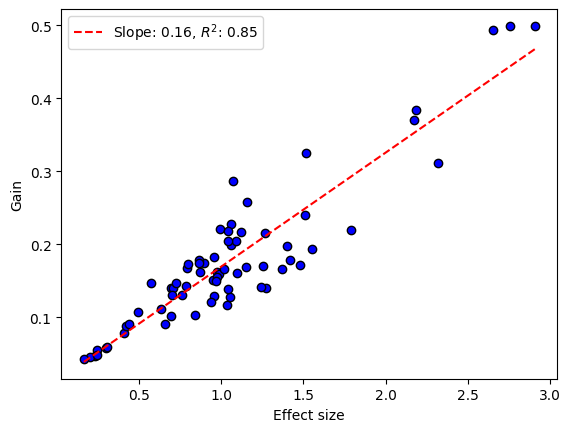

In [5]:
plt.scatter(effect_sizes, gains, color='blue', edgecolor='black'  )
#plt.errorbar(effect_sizes, gains, yerr=np.sqrt(pre_stds**2 + post_stds**2)/np.sqrt(Ns), fmt='o', color='blue', ecolor='lightgray', elinewidth=1, capsize=0)
plt.ylabel('Gain')
plt.xlabel('Effect size')

#fit line
m, b = np.polyfit(effect_sizes, gains, 1)
corr = np.corrcoef(effect_sizes, gains)[0, 1]**2
xi = np.linspace(min(effect_sizes), max(effect_sizes), 100)
plt.plot(xi, m*xi + b, 'r--', label=f'Slope: {m:.2f}, $R^2$: {corr:.2f}')
plt.legend()
#plt.title('Effect Size vs. Gain')
plt.savefig('Figs/gains.png', dpi=300)
plt.show()

## Pre Post Histograms

PreMean: mean=0.40, std=0.09, min=0.23, max=0.53
PostMean: mean=0.57, std=0.12, min=0.36, max=0.82
PreStd: mean=0.16, std=0.04, min=0.07, max=0.28
PostStd: mean=0.19, std=0.05, min=0.12, max=0.31


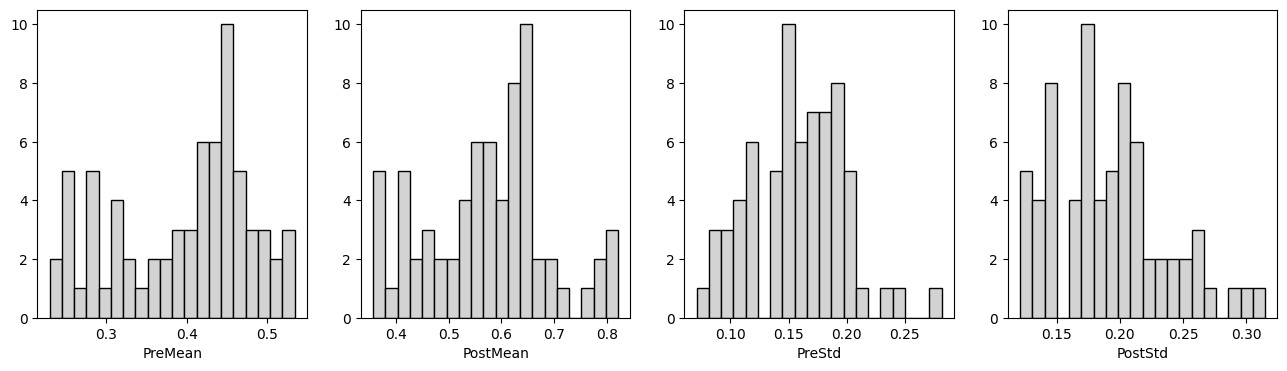

In [6]:
#plot distributions of pretest and posttest means and stds
fig, ax = plt.subplots(1, 4, figsize=(16, 4))
labels = ['PreMean', 'PostMean', 'PreStd', 'PostStd']
for i in range(len(labels)):
    ax[i].hist(data[labels[i]], bins=20, color='lightgray', edgecolor='black')
    print(f'{labels[i]}: mean={data[labels[i]].mean():.2f}, std={data[labels[i]].std():.2f}, min={data[labels[i]].min():.2f}, max={data[labels[i]].max():.2f}')
    #ax[i].set_title(labels[i])
    ax[i].set_xlabel(labels[i])

## Approximating Lec = 1 - WG - CG
In our heatmaps we estimate the amount of lecture time as 1 - WG -CG. The below plot demonstrates that this is a reasonable estimate of an upper limit on the amount of lecture for various values of WG and CG in the datset.

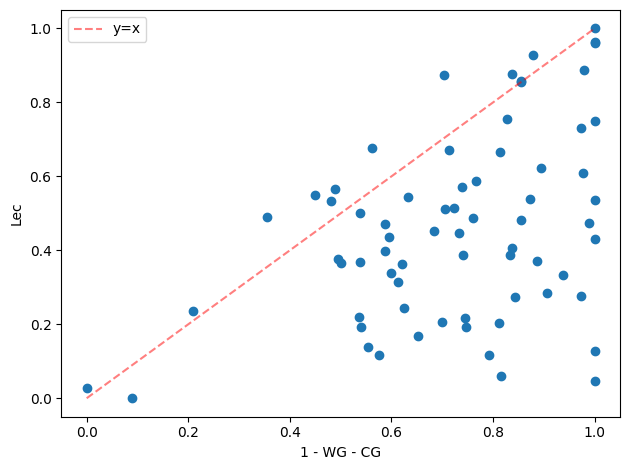

In [7]:
plt.scatter(1 - WGs -  CGs, Lecs)
plt.plot([0, 1], [0, 1], 'r--', alpha=0.5, label='y=x')

plt.xlabel('1 - WG - CG')
plt.ylabel('Lec')
#plt.title( 'Lec vs. 1- CG - WG')
plt.legend()
plt.tight_layout()
plt.savefig('Figs/lec_calc.png', dpi=300)
plt.show()

## Effect Size: Pre vs Post

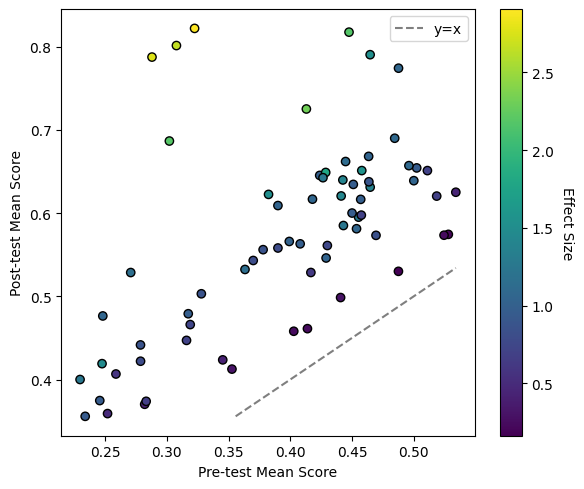

In [14]:
fig, ax = plt.subplots(1, 1, figsize=(6, 5))
ax.scatter(premeans, postmeans, c = effect_sizes, edgecolor='black', cmap='viridis')

ax.set_xlabel('Pre-test Mean Score')
ax.set_ylabel('Post-test Mean Score')
#ax.set_title('Pre-test vs. Post-test Concept Inventory Score Means ')

ax.plot([postmeans.min(), premeans.max()], [postmeans.min(), premeans.max()], 'k--', alpha=0.5, label = 'y=x')
ax.legend()

cbar = fig.colorbar(ax.collections[0], )
cbar.set_label('Effect Size', rotation=270, labelpad=15)


fig.tight_layout()
plt.savefig('Figs/pre_post.png', dpi=300)
plt.show()


## Corner Plots

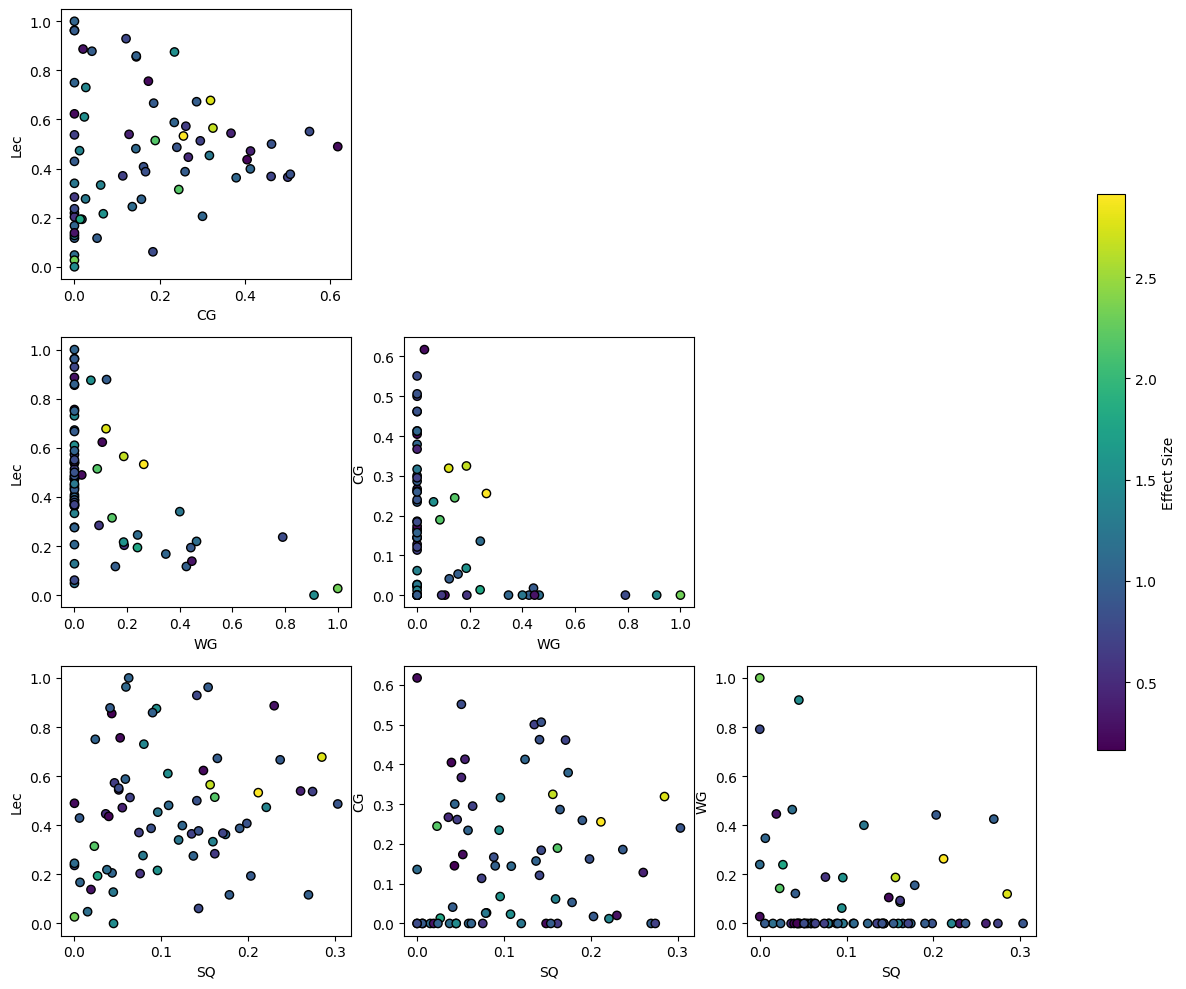

In [15]:
# make scatter plots of WG, SQ, CG, and lec vs each other
fig, ax = plt.subplots(3, 3, figsize=(13, 10))
for i in range(1, 4):
    for k in range( 3):
        if k <i:
            ax[i-1, k].scatter(COPUS_data[:, i], COPUS_data[:, k], c = effect_sizes, edgecolor='black')
            ax[i-1, k].set_xlabel(retained_labels[i])
            ax[i-1, k].set_ylabel(retained_labels[k])
        else:
            ax[i-1, k].axis('off')
#fig.suptitle('Scatter Plots of COPUS Variables Colored by Effect Size')
plt.tight_layout()
fig.colorbar(ax[0, 0].collections[0], ax=ax, location='right', label='Effect Size', shrink=0.6,)

plt.show()